# Preparación de datasets por país


Esta notebook continúa el trabajo de `01_exploration.ipynb`: toma un país y un segmento horario continuo ya identificado, valida que el rango sea utilizable sin nulos ni discontinuidades, transforma la demanda eléctrica al contrato `timestamp,y` y exporta el CSV final en `data/processed/` para notebooks posteriores de forecasting univariado.

## Importaciones y rutas

Se cargan únicamente las librerías necesarias y se definen las rutas del archivo crudo de OPSD y del directorio de salida procesado.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_CSV = PROJECT_DIR / "data/raw/time_series_60min_singleindex.csv"
PROCESSED_DIR = PROJECT_DIR / "data/processed"
TARGET_SUFFIX = "_load_actual_entsoe_transparency"


## Parámetros configurables

Estos valores deben venir de segmentos continuos detectados en `01_exploration.ipynb`; el ejemplo usa el bloque continuo más largo identificado para Irlanda.

In [ ]:
COUNTRY = "AT"

START = "2015-01-01 00:00:00+00:00"
END = "2020-09-30 23:00:00+00:0"

target_column = f"{COUNTRY}{TARGET_SUFFIX}"
start_ts = pd.Timestamp(START)
end_ts = pd.Timestamp(END)
output_csv = PROCESSED_DIR / f"{COUNTRY}.csv"

if start_ts.tz is None or end_ts.tz is None:
    raise ValueError("START y END deben incluir zona horaria UTC.")

start_ts = start_ts.tz_convert("UTC")
end_ts = end_ts.tz_convert("UTC")

if start_ts > end_ts:
    raise ValueError("START debe ser menor o igual que END.")


## Carga mínima del CSV

Se leen solo `utc_timestamp` y la columna objetivo del país seleccionado para mantener la preparación enfocada y ligera.

In [3]:
if not RAW_CSV.exists():
    raise FileNotFoundError(f"No se encontró el archivo crudo esperado: {RAW_CSV}")

header = pd.read_csv(RAW_CSV, nrows=0)
required_columns = ["utc_timestamp", target_column]
missing_columns = [column for column in required_columns if column not in header.columns]

if missing_columns:
    raise ValueError(f"Columnas requeridas no encontradas en el CSV: {missing_columns}")

raw_df = pd.read_csv(
    RAW_CSV,
    usecols=required_columns,
    parse_dates=["utc_timestamp"],
)

raw_df["utc_timestamp"] = pd.to_datetime(raw_df["utc_timestamp"], utc=True)
raw_df.head()

,utc_timestamp,AT_load_actual_entsoe_transparency
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,5946.0
2,2015-01-01 01:00:00+00:00,5726.0
3,2015-01-01 02:00:00+00:00,5347.0
4,2015-01-01 03:00:00+00:00,5249.0


## Selección de columna objetivo

Se confirma que la serie seleccionada cumple la regla establecida: demanda real de ENTSO-E con sufijo `_load_actual_entsoe_transparency`.

In [4]:
if not target_column.endswith(TARGET_SUFFIX):
    raise ValueError(f"La columna objetivo no cumple el sufijo esperado: {target_column}")

print(f"País: {COUNTRY}")
print(f"Columna objetivo: {target_column}")
print(f"Rango solicitado: {start_ts} a {end_ts}")

País: AT
Columna objetivo: AT_load_actual_entsoe_transparency
Rango solicitado: 2015-01-01 00:00:00+00:00 a 2020-09-30 23:00:00+00:00


## Filtrado por rango temporal

Se conserva únicamente el segmento definido por `START` y `END`, ambos incluidos, manteniendo timestamps UTC timezone-aware.

In [5]:
segment_df = raw_df.loc[
    raw_df["utc_timestamp"].between(start_ts, end_ts, inclusive="both"),
    ["utc_timestamp", target_column],
].copy()

if segment_df.empty:
    raise ValueError("El rango solicitado no contiene observaciones.")

segment_df.head()

,utc_timestamp,AT_load_actual_entsoe_transparency
1,2015-01-01 00:00:00+00:00,5946.0
2,2015-01-01 01:00:00+00:00,5726.0
3,2015-01-01 02:00:00+00:00,5347.0
4,2015-01-01 03:00:00+00:00,5249.0
5,2015-01-01 04:00:00+00:00,5309.0


## Validaciones

Antes de exportar se verifica existencia exacta del rango, ausencia de nulos, continuidad horaria, ausencia de duplicados y orden cronológico.

In [6]:
if segment_df["utc_timestamp"].isna().any():
    raise ValueError("Hay timestamps nulos en el segmento seleccionado.")

if segment_df[target_column].isna().any():
    null_count = int(segment_df[target_column].isna().sum())
    raise ValueError(f"El segmento contiene {null_count} valores nulos de demanda.")

if segment_df["utc_timestamp"].duplicated().any():
    duplicate_count = int(segment_df["utc_timestamp"].duplicated().sum())
    raise ValueError(f"El segmento contiene {duplicate_count} timestamps duplicados.")

if not segment_df["utc_timestamp"].is_monotonic_increasing:
    raise ValueError("Los timestamps no están en orden cronológico ascendente.")

actual_start = segment_df["utc_timestamp"].iloc[0]
actual_end = segment_df["utc_timestamp"].iloc[-1]

if actual_start != start_ts or actual_end != end_ts:
    raise ValueError(
        f"El rango exacto no existe en el CSV. Obtenido: {actual_start} a {actual_end}"
    )

expected_index = pd.date_range(start=start_ts, end=end_ts, freq="h", tz="UTC")
actual_index = pd.DatetimeIndex(segment_df["utc_timestamp"])

if not actual_index.equals(expected_index):
    missing_timestamps = expected_index.difference(actual_index)
    unexpected_timestamps = actual_index.difference(expected_index)
    raise ValueError(
        "El segmento no es continuo con frecuencia horaria. "
        f"Faltantes: {len(missing_timestamps)}; inesperados: {len(unexpected_timestamps)}"
    )

print("Validaciones completadas correctamente.")
print(f"Observaciones horarias: {len(segment_df):,}")

Validaciones completadas correctamente.
Observaciones horarias: 50,400


## Conversión al formato final

La serie se reduce al contrato estable para forecasting univariado: `timestamp` como UTC y `y` como demanda eléctrica.

In [7]:
dataset = segment_df.rename(
    columns={"utc_timestamp": "timestamp", target_column: "y"}
)[["timestamp", "y"]]

dataset.head()

,timestamp,y
1,2015-01-01 00:00:00+00:00,5946.0
2,2015-01-01 01:00:00+00:00,5726.0
3,2015-01-01 02:00:00+00:00,5347.0
4,2015-01-01 03:00:00+00:00,5249.0
5,2015-01-01 04:00:00+00:00,5309.0


## Vista previa del dataset

Se revisan dimensiones, rango final y estadísticos descriptivos básicos antes de escribir el archivo procesado.

In [8]:
print(f"Rango final: {dataset['timestamp'].min()} a {dataset['timestamp'].max()}")
print(f"Observaciones: {len(dataset):,}")

display(dataset.head())
display(dataset.tail())
dataset["y"].describe()

Rango final: 2015-01-01 00:00:00+00:00 a 2020-09-30 23:00:00+00:00
Observaciones: 50,400


,timestamp,y
1,2015-01-01 00:00:00+00:00,5946.0
2,2015-01-01 01:00:00+00:00,5726.0
3,2015-01-01 02:00:00+00:00,5347.0
4,2015-01-01 03:00:00+00:00,5249.0
5,2015-01-01 04:00:00+00:00,5309.0


,timestamp,y
50396,2020-09-30 19:00:00+00:00,6661.0
50397,2020-09-30 20:00:00+00:00,6336.0
50398,2020-09-30 21:00:00+00:00,5932.0
50399,2020-09-30 22:00:00+00:00,5628.0
50400,2020-09-30 23:00:00+00:00,5395.0


count    50400.000000
mean      7070.148631
std       1400.263167
min        664.000000
25%       5941.000000
50%       7032.000000
75%       8079.000000
max      10803.000000
Name: y, dtype: float64

## Exportación

Se crea el directorio procesado si hace falta y se exporta el dataset limpio como `data/processed/{COUNTRY}.csv`.

In [9]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
dataset.to_csv(output_csv, index=False)

print(f"Dataset exportado: {output_csv.relative_to(PROJECT_DIR)}")

Dataset exportado: data\processed\AT.csv


## Visualización rápida de la serie

Se grafica la demanda del segmento exportado solo como inspección visual mínima, sin análisis estadístico adicional ni modelado.

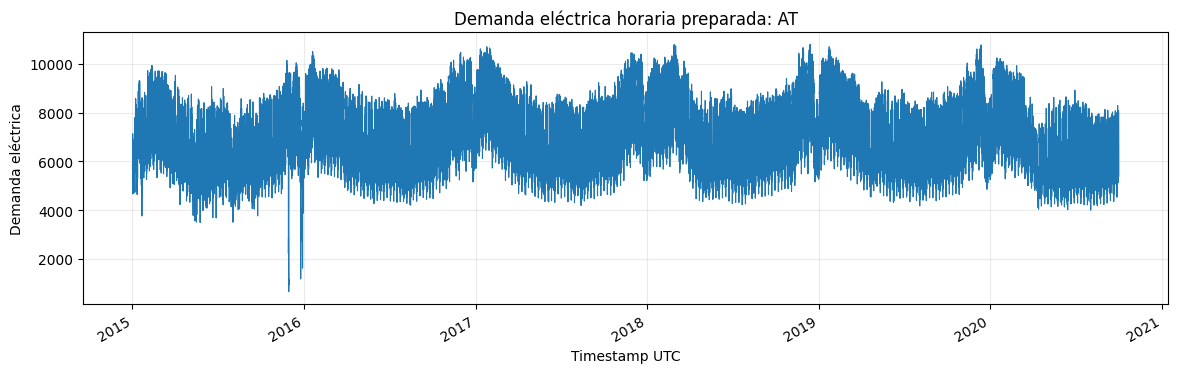

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dataset["timestamp"], dataset["y"], linewidth=0.8)
ax.set_title(f"Demanda eléctrica horaria preparada: {COUNTRY}")
ax.set_xlabel("Timestamp UTC")
ax.set_ylabel("Demanda eléctrica")
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.show()